# Modeling P-KNN - Hugo Fiévet

**Objectif :**

Etablir une performance de référence du modèle avec ses paramètres par défaut avant optimisation des hyperparamètres.

## Baseline



In [7]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, cross_validate,GridSearchCV,StratifiedGroupKFold
from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

RANDOM_STATE = 42

knn =  KNeighborsClassifier(n_jobs=-1)

xtrain_P = pd.read_csv("xtrain_P.csv")
ytrain = pd.read_csv("ytrain.csv").squeeze("columns")
kepid_train = pd.read_csv("kepid_train.csv").squeeze("columns")

Stratified_G_Kfold_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = cross_validate(estimator=knn,X=xtrain_P,y=ytrain,groups=kepid_train,scoring="f1_macro",return_train_score=True,cv=Stratified_G_Kfold_cv)
pd.DataFrame(cv_results)


,fit_time,score_time,test_score,train_score
0,0.017500,0.038961,0.655024,0.786323
1,0.017407,0.039616,0.677380,0.781224
2,0.018250,0.040547,0.683447,0.778585
3,0.018024,0.046537,0.680741,0.778842
4,0.018442,0.048522,0.677453,0.777705


In [ ]:
print("Mean train score : ",cv_results["train_score"].mean())
print("Mean validation score",cv_results["test_score"].mean())

Mean train score :  0.780535846624765
Mean validation score 0.6748090811921115


Le KNN avec ses paramètres par défaut obtient un F1-macro moyen d’environ 0,675 en validation croisée.

Les scores de validation varient entre environ 0,655 et 0,683, ce qui montre des performances relativement stables entre les différents folds.

Le F1-macro moyen d’entraînement est d’environ 0,781, soit un écart d’environ 0,106 avec le score de validation.

Cet écart indique un surapprentissage modéré : le modèle est sensiblement plus performant sur les données utilisées pour son entraînement que sur les observations de validation.

Cette baseline servira donc de référence pour vérifier si l’optimisation des hyperparamètres du KNN permet d’améliorer le F1-macro de validation tout en réduisant l’écart entre entraînement et validation.

## Tuning model

In [ ]:
settings_grid = {
    #['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights']
   "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "p":[1,2]
}

grid_search = GridSearchCV(estimator=knn,param_grid=settings_grid,scoring="f1_macro",cv=Stratified_G_Kfold_cv,return_train_score=True)

grid_search.fit(
    X=xtrain_P,
    y=ytrain,
    groups=kepid_train
)


,estimator,KNeighborsCla...ier(n_jobs=-1)
,param_grid,"{'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedGro... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_neighbors,15


In [ ]:
best_index = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)

print("Best validation F1:", grid_search.best_score_)
print(
    "Mean train F1:",
    grid_search.cv_results_["mean_train_score"][best_index]
)
print(
    "Std validation F1:",
    grid_search.cv_results_["std_test_score"][best_index]
)

Best parameters: {'n_neighbors': 15, 'p': 1, 'weights': 'uniform'}
Best validation F1: 0.6962106367035547
Mean train F1: 0.7374290653952957
Std validation F1: 0.013438395915295049


L’optimisation du KNN sélectionne `n_neighbors=15`, `p=1` et `weights="uniform"`. Le F1-macro moyen en validation passe d’environ 0,675 à 0,696, tandis que le F1-macro moyen d’entraînement diminue d’environ 0,781 à 0,737.

L’écart entre les performances d’entraînement et de validation est donc fortement réduit, ce qui indique une diminution du surapprentissage et une meilleure capacité de généralisation.

Le choix de n_neighbors=15, supérieur à la valeur par défaut de 5, produit une frontière de décision plus lissée. De plus, p=1 correspond à la distance de Manhattan, qui semble ici mieux adaptée aux données que la distance euclidienne utilisée par défaut.

Le faible écart-type du score de validation (≈ 0,013) indique également que les performances sont relativement stables entre les folds

## Final evaluation



In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
X_test_P = pd.read_csv("xtest_P.csv")
y_test = pd.read_csv("ytest.csv").squeeze("columns")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X=X_test_P)

class_report = classification_report(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy :",accuracy )
print("Precision macro :",precision )
print("Recall macro :",recall )
print("F1 macro :", f1)

Accuracy : 0.7213459516298633
Precision macro : 0.6848151294410316
Recall macro : 0.6957868113618767
F1 macro : 0.686636483439398


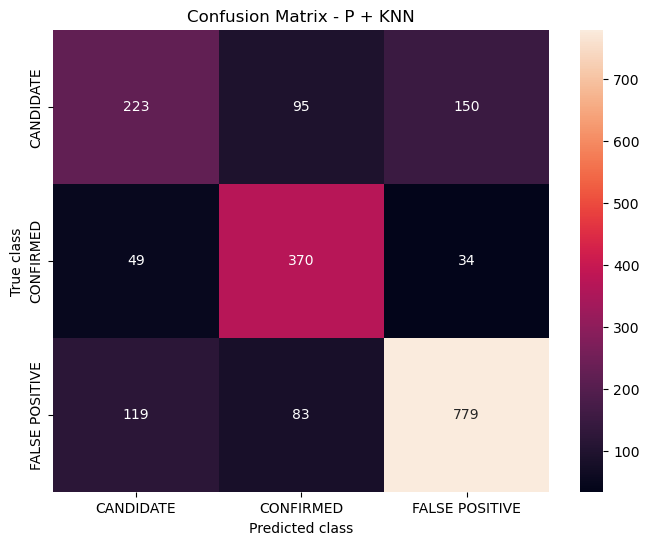

In [12]:
labels = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix - P + KNN")

plt.show()

La matrice de confusion montre que le modèle KNN utilisant la sélection personnelle reconnaît correctement une grande partie des classes CONFIRMED et FALSE POSITIVE, tandis que la classe CANDIDATE reste la plus difficile à prédire.

Parmi les 468 CANDIDATE, 223 sont correctement classés, tandis que 95 sont prédits CONFIRMED et 150 FALSE POSITIVE. La principale confusion concerne donc les candidats interprétés comme faux positifs.

Pour les 453 CONFIRMED, 370 sont correctement identifiés. Les erreurs sont limitées à 49 observations prédites CANDIDATE et 34 FALSE POSITIVE.

Enfin, parmi les 981 FALSE POSITIVE, 779 sont correctement classés. Les principales erreurs correspondent à 119 observations prédites CANDIDATE, tandis que 83 sont prédites CONFIRMED.

La classe CANDIDATE constitue donc à nouveau la principale difficulté du modèle. Cela suggère que ses caractéristiques sont moins clairement séparées de celles des deux autres classes que ne le sont CONFIRMED et FALSE POSITIVE

## Model limits



Comme observé avec les autres modèles, la difficulté concernant CANDIDATE peut être liée à l’ambiguïté intrinsèque de cette classe. Un candidat KOI n’est justement pas encore clairement confirmé ou rejeté, ce qui peut expliquer qu’il partage certaines caractéristiques avec les deux autres catégories